# Análisis Multivariante: Modelado Predictivo con Random Forest


**Analistas:** Emilio, Nuria (Perfil y Desempeño)

Para consolidar nuestros hallazgos y validar la importancia real de cada factor, implementaremos un modelo de Machine Learning multivariante: **Random Forest Regressor**.

**Justificación Técnica:**
1. **Multivariante:** A diferencia de Spearman (que cruza variables de dos en dos), Random Forest evalúa todas las características simultáneamente, aislando el peso real de cada una.
2. **No linealidad:** Es capaz de capturar relaciones complejas (como el efecto en "U" de la carga de trabajo) sin necesidad de transformar los datos.
3. **Interpretabilidad (Feature Importance):** Nos permite extraer un porcentaje exacto de cuánto contribuye cada variable a predecir el desempeño y el absentismo, dándonos el "Ranking Definitivo" para la toma de decisiones en RRHH.

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor


/var/folders/7n/r9wpqsvn3fjdmkznp35dflqh0000gn/T/ipykernel_2655/360330670.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancia_des, x='Importancia', y='Variable', palette='viridis', ax=ax)


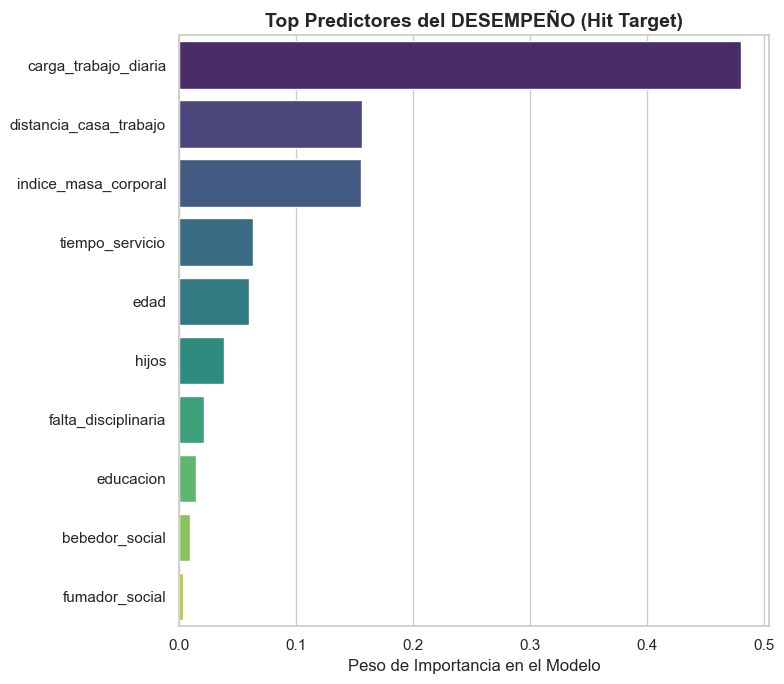

--- RANKING EXACTO: VARIABLES QUE EXPLICAN EL DESEMPEÑO ---


,Variable,Importancia
8,carga_trabajo_diaria,48.04%
7,distancia_casa_trabajo,15.64%
4,indice_masa_corporal,15.54%
2,tiempo_servicio,6.31%
1,edad,5.96%
3,hijos,3.78%
9,falta_disciplinaria,2.11%
0,educacion,1.38%
5,bebedor_social,0.94%
6,fumador_social,0.30%


In [10]:
# Cargar el dataset limpio
df = pd.read_csv('data_cleaning_2026_27_04.csv')

# Preparar el Perfil Único (Agrupación para evitar sesgo de múltiples registros por empleado)
df_perfil = df.groupby('id').agg({
    'cumplimiento_objetivo': 'mean',
    'horas_ausentismo': 'sum',
    'educacion': 'first',
    'edad': 'first',
    'tiempo_servicio': 'first',
    'hijos': 'first',
    'indice_masa_corporal': 'first',
    'bebedor_social': 'first',
    'fumador_social': 'first',
    'distancia_casa_trabajo': 'first',
    'carga_trabajo_diaria': 'mean',
    'falta_disciplinaria': 'max'
}).reset_index()

# Definir las variables predictoras (X) y los objetivos (y)
features = [
    'educacion', 'edad', 'tiempo_servicio', 'hijos', 'indice_masa_corporal', 
    'bebedor_social', 'fumador_social', 'distancia_casa_trabajo', 
    'carga_trabajo_diaria', 'falta_disciplinaria'
]

X = df_perfil[features]
y_desempeno = df_perfil['cumplimiento_objetivo']

# Entrenar los Modelos Random Forest
# Usamos random_state para que los resultados sean reproducibles
rf_desempeno = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=5)
rf_desempeno.fit(X, y_desempeno)


# Extraer la Importancia de las Variables (Feature Importance)
importancia_des = pd.DataFrame({
    'Variable': features,
    'Importancia': rf_desempeno.feature_importances_
}).sort_values(by='Importancia', ascending=False)


# Visualización del Ranking Multivariante
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 7))

# Gráfico: Predictores del Desempeño
sns.barplot(data=importancia_des, x='Importancia', y='Variable', palette='viridis', ax=ax)
ax.set_title('Top Predictores del DESEMPEÑO (Hit Target)', fontweight='bold', fontsize=14)
ax.set_xlabel('Peso de Importancia en el Modelo')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

# Imprimir DataFrames para análisis detallado
print("--- RANKING EXACTO: VARIABLES QUE EXPLICAN EL DESEMPEÑO ---")
display(importancia_des.style.format({'Importancia': '{:.2%}'}))

### Conclusiones Estratégicas: Modelo Predictivo (Random Forest)

La implementación del algoritmo multivariante **Random Forest** marca un antes y un después en nuestro análisis. Al evaluar todo el ecosistema del empleado de forma simultánea, el modelo elimina sesgos e intuiciones, revelando dónde reside realmente el 80% del impacto en nuestra operativa. 

A continuación, los *insights* definitivos para la toma de decisiones en Dirección:

#### El Desempeño: La Operativa devora al Currículum
El algoritmo demuestra que el rendimiento no es un problema de "falta de talento", sino un reto de gestión de flujos de trabajo y bienestar físico.
* **(Carga de Trabajo - 48%):** La cantidad de trabajo diario es, con una diferencia abismal, el motor absoluto del *Hit Target*. Esto confirma que el rendimiento de nuestra plantilla es altamente reactivo a la presión.
* **La Logística y el Físico pesan más que el CV (~31% combinado):** La distancia al trabajo y el Índice de Masa Corporal (IMC) son los siguientes grandes predictores. El desgaste de un viaje largo y la salud física general impactan directamente en la energía para alcanzar las metas.
* **Cambio de Paradigma:** Las variables sociodemográficas clásicas (Educación, Edad, Estado Civil) han caído al fondo del ranking. Un empleado con alta educación bajo una mala carga de trabajo y a 2 horas de la oficina, no podrá sostener sus KPIs.

---

### Plan de Acción Recomendado

Basado en la predicción matemática del modelo, estas son las tres palancas estratégicas con mayor Retorno de Inversión (ROI) para Recursos Humanos:

1. **Evolución en la Evaluación de Desempeño:** Instruir a los *managers* para que, ante caídas en los KPIs, auditen primero **cómo está distribuida la carga de trabajo** en el equipo antes de penalizar al empleado individual.
2. **Estrategia de Retención Logística:** Implementar políticas de **teletrabajo o flexibilidad horaria** prioritaria para los perfiles con mayor distancia al centro de trabajo. Eliminar el desgaste del viaje mejorará automáticamente su *Hit Target* y reducirá su probabilidad de falta.
3. **Rediseño de Beneficios Corporativos:** Redirigir parte del presupuesto de formación genérica hacia **programas de bienestar físico** (nutrición, ergonomía, actividad física) para mitigar el impacto negativo (15.5%) que el desgaste de salud tiene sobre la productividad.